Hands-On Lab: Sequence Modeling + Mentor Review     
● Step 1: Build and train an LSTM on a sequential dataset (e.g. text sentiment or a time series) and record its metric.     
● Step 2: Compare the LSTM against a plain RNN or a non-sequential baseline and note the difference.        
● Step 3: Explain, in Markdown, why order-awareness helped on this data.        
● Step 4: Open a pull request with the current project notebook for the mid-sprint Mentor Code & Notebook Review and address the feedback.      

### Prepare the Dataset:

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#### `Train-data`:

##### load df_train:

In [2]:
train_path = r"..\Data\mitbih_test.csv\mitbih_train.csv"

df_train = pd.read_csv(train_path, header=None) # header=None because this dataset does not use a normal header row

print(df_train.shape)
df_train.head()

(87554, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# checking the Last column (the heartbeat class label.)
print(df_train.iloc[:, -1].value_counts())

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


| Label | General meaning               |
| ----: | ----------------------------- |
|   `0` | Normal beat                   |
|   `1` | Supraventricular ectopic beat |
|   `2` | Ventricular ectopic beat      |
|   `3` | Fusion beat                   |
|   `4` | Unknown / other beat          |


In [4]:
# everything except the last column belongs to the ECG sequence

print("Number of signal values:", df_train.shape[1] - 1) # columns -1 label column
print("Number of samples:", df_train.shape[0]) # rows

# So each row is: 187 ECG measurements + 1 label column

Number of signal values: 187
Number of samples: 87554


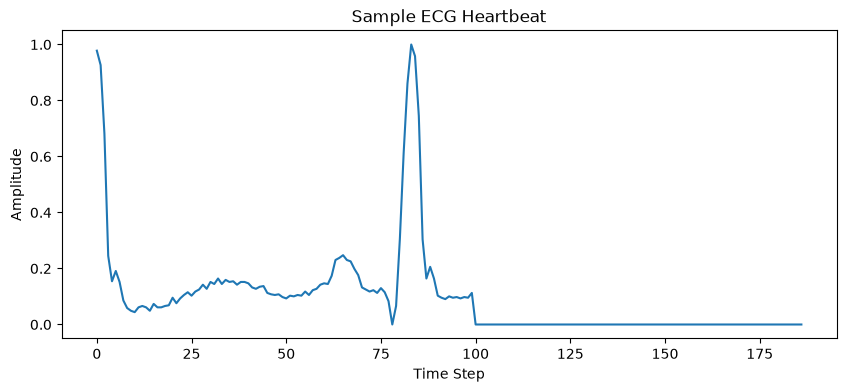

In [5]:
# inspecting one signal (-one row- without the last column, which is the label column.)
sample_signal = df_train.iloc[0, :-1]

plt.figure(figsize=(10, 4))
plt.plot(sample_signal)
plt.title("Sample ECG Heartbeat")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

##### Split into X_train & y_train

In [ ]:
X_train = df_train.iloc[:,:-1] # all columns except the last one (contains only the ECG signal values.)

y_train = df_train.iloc[:, -1] # contains the heart beat class label.



y_train = y_train.astype(int) # turn it into integers ince they are class id's (makes them easier to read)


In [23]:
print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

print(y_train.value_counts())

X shape: (87554, 187)
y shape: (87554,)
187
0    72471
4     6431
2     5788
1     2223
3      641
Name: count, dtype: int64


In [8]:
# checking the all values across time stamps for the (first row)
print(X_train.iloc[0])

0      0.977941
1      0.926471
2      0.681373
3      0.245098
4      0.154412
         ...   
182    0.000000
183    0.000000
184    0.000000
185    0.000000
186    0.000000
Name: 0, Length: 187, dtype: float64


This gives the 187 values of the first heartbeat. (first row)

sample 0:

[0.97, 0.92, 0.68, 0.24, 0.15, ...]     
Each number is one point in the sequence.   
`order matters ! `

In [24]:
# checking the label of the (first row)
print("Class:", y_train.iloc[0]) 

Class: 0


##### Reshaping (Suiting) X_train & y_train for keras:

`RNN layers expect three dimensions` (samples, timesteps, features).     
our current shape is (samples, timesteps). 
     
`note`: we only have 1 features because at each time stamp we only have 1 feature recorded (ECG amplitude).     

In [25]:
# pandas objects are not compatible with keras,
# so they need to be converted to numpy arrays first.

X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [26]:
print("X_train shape before reshaping :", X_train.shape)

X_train = X_train.reshape(X_train.shape[0] ,  X_train.shape[1] ,  1)

print("X_train shape after reshaping :", X_train.shape)

X_train shape before reshaping : (87554, 187)
X_train shape after reshaping : (87554, 187, 1)


A sample is a sequence of 187 time steps, and each time step contains 1 feature.

#### `Test-data`:

##### load df_test:

In [12]:

test_path = r"..\Data\mitbih_test.csv\mitbih_test.csv"

df_test = pd.read_csv(test_path,header=None) # header=None because this dataset does not use a normal header row

print(df_test.shape)
df_test.head()

(21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# checking the Last column (the heartbeat class label.)
print(df_test.iloc[:, -1].value_counts())

187
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64


| Label | General meaning               |
| ----: | ----------------------------- |
|   `0` | Normal beat                   |
|   `1` | Supraventricular ectopic beat |
|   `2` | Ventricular ectopic beat      |
|   `3` | Fusion beat                   |
|   `4` | Unknown / other beat          |


In [14]:
# everything except the last column belongs to the ECG sequence

print("Number of signal values:", df_test.shape[1] - 1) # columns -1 label column
print("Number of samples:", df_test.shape[0]) # rows

# So each row is: 187 ECG measurements + 1 label column

Number of signal values: 187
Number of samples: 21892


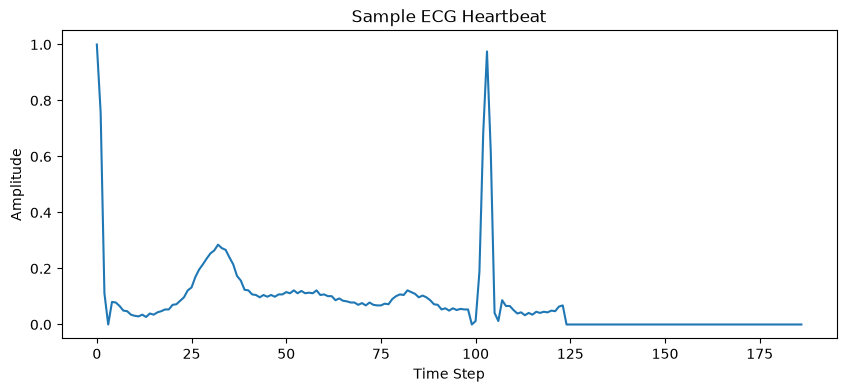

In [15]:
# inspecting one signal (-one row- without the last column, which is the label column.)
sample_signal = df_test.iloc[0, :-1]

plt.figure(figsize=(10, 4))
plt.plot(sample_signal)
plt.title("Sample ECG Heartbeat")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

##### Split into X_test & y_test

In [27]:
X_test = df_test.iloc[:,:-1] # all columns except the last one (contains only the ECG signal values.)

y_test = df_test.iloc[:, -1] # contains the heart beat class label.



y_test = y_test.astype(int) # turn it into integers ince they are class id's (makes them easier to read)


In [28]:
print("X shape:", X_test.shape)
print("y shape:", y_test.shape)

print(y_test.value_counts())

X shape: (21892, 187)
y shape: (21892,)
187
0    18118
4     1608
2     1448
1      556
3      162
Name: count, dtype: int64


In [18]:
print(X_test.iloc[0])

0      1.000000
1      0.758264
2      0.111570
3      0.000000
4      0.080579
         ...   
182    0.000000
183    0.000000
184    0.000000
185    0.000000
186    0.000000
Name: 0, Length: 187, dtype: float64


This gives the 187 values of the first heartbeat. (first row)

sample 0:

[0.93, 0.87, 0.64, 0.41, 0.29, ...]     
Each number is one point in the sequence.   
`order matters ! `

In [29]:
print("Class:", y_test.iloc[0])

Class: 0


##### Reshaping (Suiting) X_test & y_test for keras:

our `currnt shape` is (21892, 187).       
Still this can't be given to keras right now.        
 since it `RNN layers expect three dimensions` (samples, timesteps, features).        

So for test data set we should have :       
samples = 21892     
timesteps = 187     
features = 1        

`note`: features = 1  , because at each time stamp we only have one measurement (ECG amplitude)


In [30]:
# pandas objects are not compatible with keras,
# so they need to be converted to numpy arrays first.

X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

print(type(X_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [31]:
print("X_test shape before reshaping :", X_test.shape)

X_test = X_test.reshape(X_test.shape[0] ,  X_test.shape[1] ,  1)

print("X_test shape after reshaping :", X_test.shape)

X_test shape before reshaping : (21892, 187)
X_test shape after reshaping : (21892, 187, 1)


### RNN & LSTM

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  LSTM, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)



#### Fixes before models:

##### Explicitly stratified validation set:

In [47]:
X_train_split , X_val, y_train_split , y_val = train_test_split(X_train, y_train, test_size=.2, random_state=42, stratify= y_train)

In [48]:
# check that it worked

print("Training classes:")
print( np.unique( y_train_split, return_counts=True) )

print("\nValidation classes:")
print( np.unique( y_val, return_counts=True) )

Training classes:
(array([0, 1, 2, 3, 4]), array([57977,  1778,  4630,   513,  5145]))

Validation classes:
(array([0, 1, 2, 3, 4]), array([14494,   445,  1158,   128,  1286]))


##### Class weights balance:

Since `y_train` classes are highly imbalanced or skewed.    
class weighting would be of benefit.    

**Note**: since we are now training on `y_train_split` it will `replace` `y_train`.

In [49]:
# compute the weight for each unique class in `y_train_split`.

classes = np.unique(y_train_split) 

weights = compute_class_weight( class_weight = "balanced",  classes = classes,   y = y_train_split)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.2416234023837039), np.int64(1): np.float64(7.878852643419573), np.int64(2): np.float64(3.0256155507559397), np.int64(3): np.float64(27.307212475633527), np.int64(4): np.float64(2.722759961127308)}


balanced Class weights for y_train:     
0 : 0.24     
1 : 7.87     
2 : 3.02     
3 : 27.31        
4 : 2.72     

**Note**: `since stratify was used`, `even though y_train_split replaced y_train` the class weights are the same.

#### `Simple-RNN`:

##### Model:

In [50]:
rnn_model = Sequential([
    
    SimpleRNN(
        64,                   # 64 (hidden units) internal memory values
        input_shape= (187,1), # `input_shape= (187,1)` means: 187 time steps 1 feature at each time step
        activation= "tanh"), 
    
    Dense(5, activation="softmax") # output has 5 neurons since `heartbeat 'y' has 5 classes` 
                                   # we get one output probability for each heartbeat class.
    
])

c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,649 (53.32 KB)

 Trainable params: 4,549 (17.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,100 (35.55 KB)

In [52]:
# compile
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # sparse.. is used since the labels are integers (0, 1, 2, 3, 4) rather than one-hot vectors (0,1).
    metrics=["accuracy"]
)

In [ ]:
# fit (train)
history_rnn = rnn_model.fit(
    X_train_split, 
    y_train_split,
    epochs= 10,
    batch_size= 64,
    validation_data= (X_val,y_val), # it still holds 20% of the set but now its class wieghts are balanced. (validation_split → validation_data)
    class_weight= class_weights # to mitigate the class imbalance
)

Epoch 1/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.1057 - loss: 1.6203 - val_accuracy: 0.0382 - val_loss: 1.6600
Epoch 2/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1124 - loss: 1.6073 - val_accuracy: 0.1076 - val_loss: 1.4862
Epoch 3/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.1445 - loss: 1.5879 - val_accuracy: 0.0254 - val_loss: 1.6742
Epoch 4/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1504 - loss: 1.5588 - val_accuracy: 0.0918 - val_loss: 1.4967
Epoch 5/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.1515 - loss: 1.5341 - val_accuracy: 0.1094 - val_loss: 1.6249
Epoch 6/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.1945 - loss: 1.5424 - val_accuracy: 0.0890 - val_loss: 1.5157
Epoch 7/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.1730 - loss: 1.5169 - val_accuracy: 0.1118 - val_loss: 1.5167
Epoch 8/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.1442 -

**Problem** 

The first run (10 epochs) gave:

accuracy → 1    
validation accuracy → exactly 13.87% every epoch    
validation loss     → 7.8 → 13.     

which reveals a **`data spliting problem`**. 

Most probably because of (validation_split=0.2), `since it takes the last 20%` of the data.     
our dataset seems to be grouped by classes, and class 0 represents 72,471 out of 87,554 total samples,          

So `taking the last 20% as validation set would leave it with predicting nothing but the majority class`.  
That can be clear by looking at the perfect accuracy score,     
 which shows that the `RNN -learned that everything is class 0-`.


**Fix**

Instead of using (validation_split=0.2), we will `explicitly create a stratified validation set`.

by using (stratify = y_train), we keep approximately the same class percentages in both sets.


##### Plots:

- Loss plot

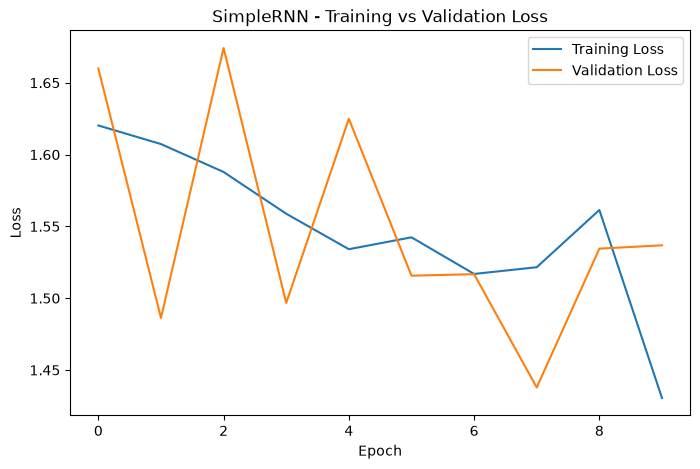

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["loss"], label="Training Loss")

plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimpleRNN - Training vs Validation Loss")
plt.legend()

plt.show()

- Accuracy plot

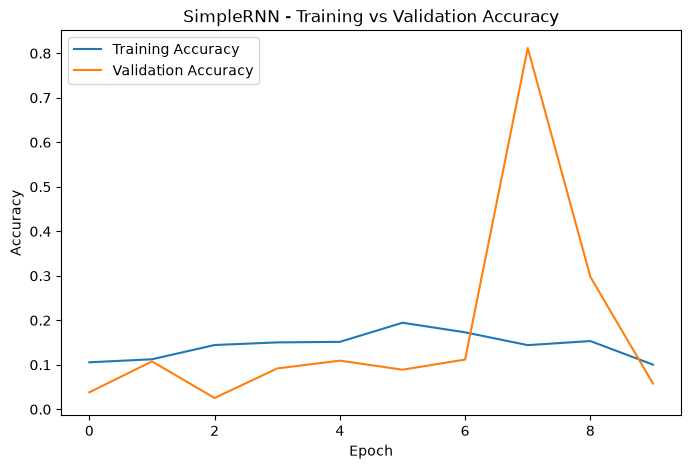

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["accuracy"], label="Training Accuracy")

plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SimpleRNN - Training vs Validation Accuracy")
plt.legend()

plt.show()

##### Evaluation:

In [57]:
# get predictions (Simple RNN model)

y_pred_prob = rnn_model.predict(X_test)

y_pred = np.argmax(y_pred_prob , axis=1) # since the output layer gives 5 outputs
                                         # argmax returns the index of the largest one

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [70]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

f1 = f1_score( y_test,  y_pred, average="macro", zero_division=0)

print("Simple RNN Model Metrics: \n")
print(f"Accuracy: {accuracy:.3f}")
print(f"Macro Precision: {precision:.3f}")
print(f"Macro Recall: {recall:.3f}")
print(f"Macro F1-score: {f1:.3f}")

Simple RNN Model Metrics: 

Accuracy: 0.056
Macro Precision: 0.203
Macro Recall: 0.426
Macro F1-score: 0.136


In [69]:
print("Detailed per class report: ")
print( classification_report(y_test, y_pred, digits=4, zero_division=0 ))

Detailed per class report: 
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     18118
           1     0.0483    0.7770    0.0910       556
           2     0.3325    0.0877    0.1388      1448
           3     0.0130    0.9383    0.0256       162
           4     0.6192    0.3246    0.4259      1608

    accuracy                         0.0563     21892
   macro avg     0.2026    0.4255    0.1363     21892
weighted avg     0.0688    0.0563    0.0430     21892



In [65]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix: \n")
print(cm)

Confusion Matrix: 

[[   0 8003  237 9622  256]
 [   0  432    2  119    3]
 [   0  389  127  870   62]
 [   0    8    2  152    0]
 [   0  105   14  967  522]]


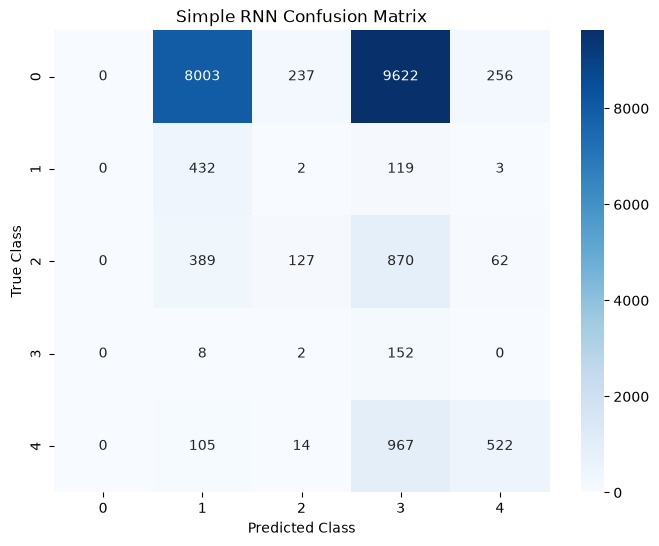

In [68]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Simple RNN Confusion Matrix")

plt.show()

#### `LSTM`:

##### Model

In [72]:
lstm_model = Sequential([
    LSTM(64, input_shape =(187,1)),
    Dense(5, activation="softmax")
])

c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,221 (67.27 KB)

 Trainable params: 17,221 (67.27 KB)

 Non-trainable params: 0 (0.00 B)

It has much more parameters than the simple RNN.

In [87]:
# compile
lstm_model.compile(
    optimizer=Adam(learning_rate=0.0001), # trying a samller learning rate since LSTM is complex it requires more time (smaller steps) so it doesnt overshoot.
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [88]:
# early stopping to prevent overfitting and save time in training.

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [89]:
# fit (train) using the same stratified split and class weights
history_lstm = lstm_model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weights,
    callbacks = [early_stop]
)

Epoch 1/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 106s 96ms/step - accuracy: 0.2084 - loss: 1.5497 - val_accuracy: 0.2184 - val_loss: 1.6322
Epoch 2/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 113s 69ms/step - accuracy: 0.2508 - loss: 1.2554 - val_accuracy: 0.2893 - val_loss: 1.5289
Epoch 3/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - accuracy: 0.2658 - loss: 1.2120 - val_accuracy: 0.2633 - val_loss: 1.4261
Epoch 4/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 151s 91ms/step - accuracy: 0.3589 - loss: 1.2898 - val_accuracy: 0.4284 - val_loss: 1.4821
Epoch 5/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.3654 - loss: 1.1950 - val_accuracy: 0.3602 - val_loss: 1.4087
Epoch 6/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 73s 67ms/step - accuracy: 0.3644 - loss: 1.1555 - val_accuracy: 0.3685 - val_loss: 1.3794
Epoch 7/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.3357 - loss: 1.1675 - val_accuracy: 0.3111 - val_loss: 1.4034
Epoch 8/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 118s 53ms/step - accuracy: 0.34

##### Plots:

- Loss plot

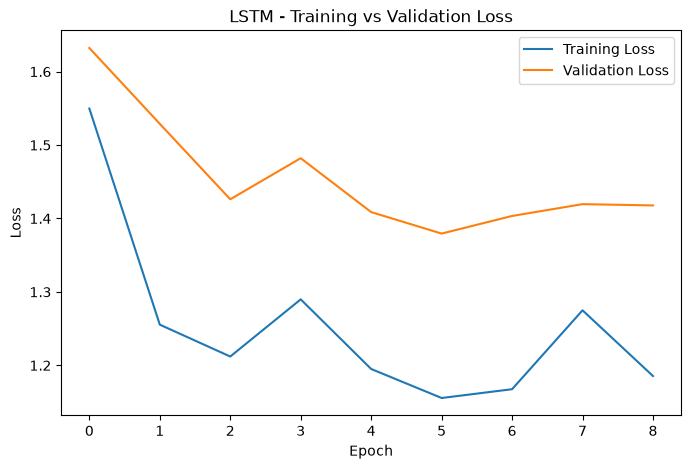

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(history_lstm.history["loss"], label="Training Loss")

plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM - Training vs Validation Loss")
plt.legend()

plt.show()

- Accuracy plot

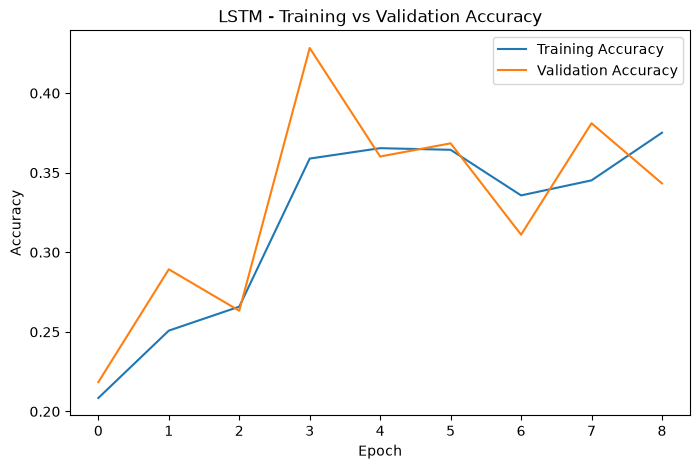

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(history_lstm.history["accuracy"], label="Training Accuracy")

plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM - Training vs Validation Accuracy")
plt.legend()

plt.show()

##### Evaluation:

In [92]:
# get predictions (Simple RNN model)

y_pred_lstm_prob = lstm_model.predict(X_test)

y_pred_lstm = np.argmax(y_pred_lstm_prob , axis=1) # since the output layer gives 5 outputs
                                         # argmax returns the index of the largest one

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step


In [93]:
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)

precision_lstm = precision_score(y_test, y_pred_lstm, average="macro", zero_division=0)

recall_lstm = recall_score(y_test, y_pred_lstm, average="macro", zero_division=0)

f1_lstm = f1_score( y_test,  y_pred_lstm, average="macro", zero_division=0)

print("LSTM Model Metrics: \n")
print(f"Accuracy: {accuracy_lstm:.3f}")
print(f"Macro Precision: {precision_lstm:.3f}")
print(f"Macro Recall: {recall_lstm:.3f}")
print(f"Macro F1-score: {f1_lstm:.3f}")

LSTM Model Metrics: 

Accuracy: 0.368
Macro Precision: 0.283
Macro Recall: 0.542
Macro F1-score: 0.243


In [94]:
print("LSTM Detailed per class report: ")
print( classification_report(y_test, y_pred_lstm, digits=4, zero_division=0 ))

LSTM Detailed per class report: 
              precision    recall  f1-score   support

           0     0.9511    0.3265    0.4861     18118
           1     0.0770    0.4101    0.1297       556
           2     0.1098    0.2445    0.1516      1448
           3     0.0397    0.8395    0.0759       162
           4     0.2355    0.8887    0.3723      1608

    accuracy                         0.3683     21892
   macro avg     0.2826    0.5418    0.2431     21892
weighted avg     0.8140    0.3683    0.4435     21892



In [95]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

print("LSTM Confusion Matrix: \n")
print(cm_lstm)

LSTM Confusion Matrix: 

[[5915 2412 2759 3008 4024]
 [  65  228   95   61  107]
 [ 190  197  354  200  507]
 [  15    9    1  136    1]
 [  34  114   14   17 1429]]


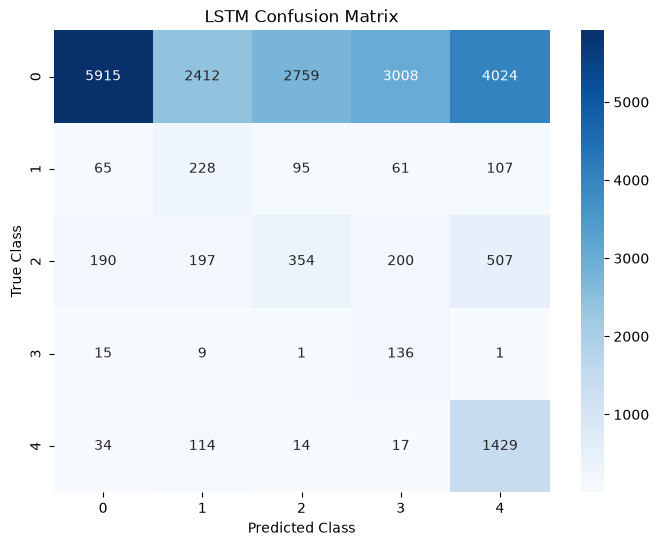

In [96]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm_lstm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("LSTM Confusion Matrix")

plt.show()

#### `Simple-RNN & LSTM Comparison`:

**ONLY 10 EPOCHS**

| Model     |  Accuracy | Macro Precision | Macro Recall | Macro F1-score |
| --------- | --------: | --------------: | -----------: | -------------: |
| SimpleRNN |     0.056 |           0.203 |        0.426 |          0.136 |
| LSTM      | **0.368** |       **0.283** |    **0.542** |      **0.243** |

The `LSTM` performed better than the `SimpleRNN` across all of the main evaluation metrics.

The SimpleRNN achieved only `5.6% accuracy` and a macro F1-score of `0.136`. It also completely failed to correctly detect class `0`.

The LSTM improved accuracy to approximately `36.8%`, macro recall to `0.542`, and macro F1-score to `0.243`.

Both models still struggled because the dataset is highly imbalanced and class weighting makes the models give more importance to the minority heartbeat classes.   
   However, the LSTM produced a better overall balance between the classes.

Therefore, the `LSTM was the stronger sequential model` for this ECG classification task.


#### `Why Order-Awareness Helps With ECG Data`:

An ECG heartbeat is a `sequence`, meaning that the order of its measurements is important.

Each sample contains `187 ECG values` recorded across consecutive time steps. A value at one time step is related to the values that came before and after it.

RNNs process the sequence in order and keep information from previous time steps using a hidden state. This allows the model to learn patterns based on how the ECG signal changes over time instead of treating every value independently.

The `LSTM` improves this further by using a memory mechanism that decides what information should be remembered or forgotten. This helps it capture longer relationships within the heartbeat signal.

This is why a sequential model such as an `RNN or LSTM` is appropriate for ECG data, and the better results of the LSTM suggest that its improved memory mechanism helped it learn the temporal structure of the heartbeat more effectively.
